# Week 0 Lab Assignment — Natural Language Processing (CSET346)

In [1]:
import os
os.makedirs("data", exist_ok=True)
print("Working directory ready:", os.path.abspath("data"))

Working directory ready: /Users/swapnil/Documents/NLP/week1/data


## Task 1 — Getting Familiar with the Environment

### 1. Tabular / Interchange Data Formats — `.dat`, `.csv`, `.tsv`, `.arff`

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df_tabular = iris.frame.copy()
df_tabular.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "target"]
df_tabular["species"] = df_tabular["target"].map(dict(enumerate(iris.target_names)))
df_tabular.insert(0, "id", range(1, len(df_tabular) + 1))

# .dat (generic tabular, whitespace-separated)
df_tabular.to_csv("data/sample.dat", sep=" ", index=False)
# .csv
df_tabular.to_csv("data/sample.csv", index=False)
# .tsv
df_tabular.to_csv("data/sample.tsv", sep="\t", index=False)

print("Wrote sample.dat, sample.csv, sample.tsv from the Iris dataset")

Wrote sample.dat, sample.csv, sample.tsv from the Iris dataset


In [3]:
# Read each format back
df_dat = pd.read_csv("data/sample.dat", sep=" ")
df_csv = pd.read_csv("data/sample.csv")
df_tsv = pd.read_csv("data/sample.tsv", sep="\t")

for name, d in [(".dat", df_dat), (".csv", df_csv), (".tsv", df_tsv)]:
    print(f"--- {name} ---  shape={d.shape}, size={d.size}, dims={d.ndim}")
df_csv.head()

--- .dat ---  shape=(150, 7), size=1050, dims=2
--- .csv ---  shape=(150, 7), size=1050, dims=2
--- .tsv ---  shape=(150, 7), size=1050, dims=2


,id,sepal_length,sepal_width,petal_length,petal_width,target,species
0,1,5.1,3.5,1.4,0.2,0,setosa
1,2,4.9,3.0,1.4,0.2,0,setosa
2,3,4.7,3.2,1.3,0.2,0,setosa
3,4,4.6,3.1,1.5,0.2,0,setosa
4,5,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# .arff (Attribute-Relation File Format) — recreating the famous UCI/Weka "iris.arff"
import arff  # liac-arff

arff_data = {
    "description": "Iris Plants Database (Fisher, 1936) - the canonical UCI/Weka ARFF example",
    "relation": "iris",
    "attributes": [
        ("sepal_length", "NUMERIC"),
        ("sepal_width", "NUMERIC"),
        ("petal_length", "NUMERIC"),
        ("petal_width", "NUMERIC"),
        ("species", list(iris.target_names)),
    ],
    "data": df_tabular[["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]].values.tolist(),
}
with open("data/sample.arff", "w") as f:
    arff.dump(arff_data, f)

with open("data/sample.arff") as f:
    loaded_arff = arff.load(f)

df_arff = pd.DataFrame(loaded_arff["data"], columns=[a[0] for a in loaded_arff["attributes"]])
print("ARFF relation:", loaded_arff["relation"])
print("shape:", df_arff.shape, "attributes:", loaded_arff["attributes"])
df_arff.head()

ARFF relation: iris
shape: (150, 5) attributes: [('sepal_length', 'NUMERIC'), ('sepal_width', 'NUMERIC'), ('petal_length', 'NUMERIC'), ('petal_width', 'NUMERIC'), ('species', ['setosa', 'versicolor', 'virginica'])]


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


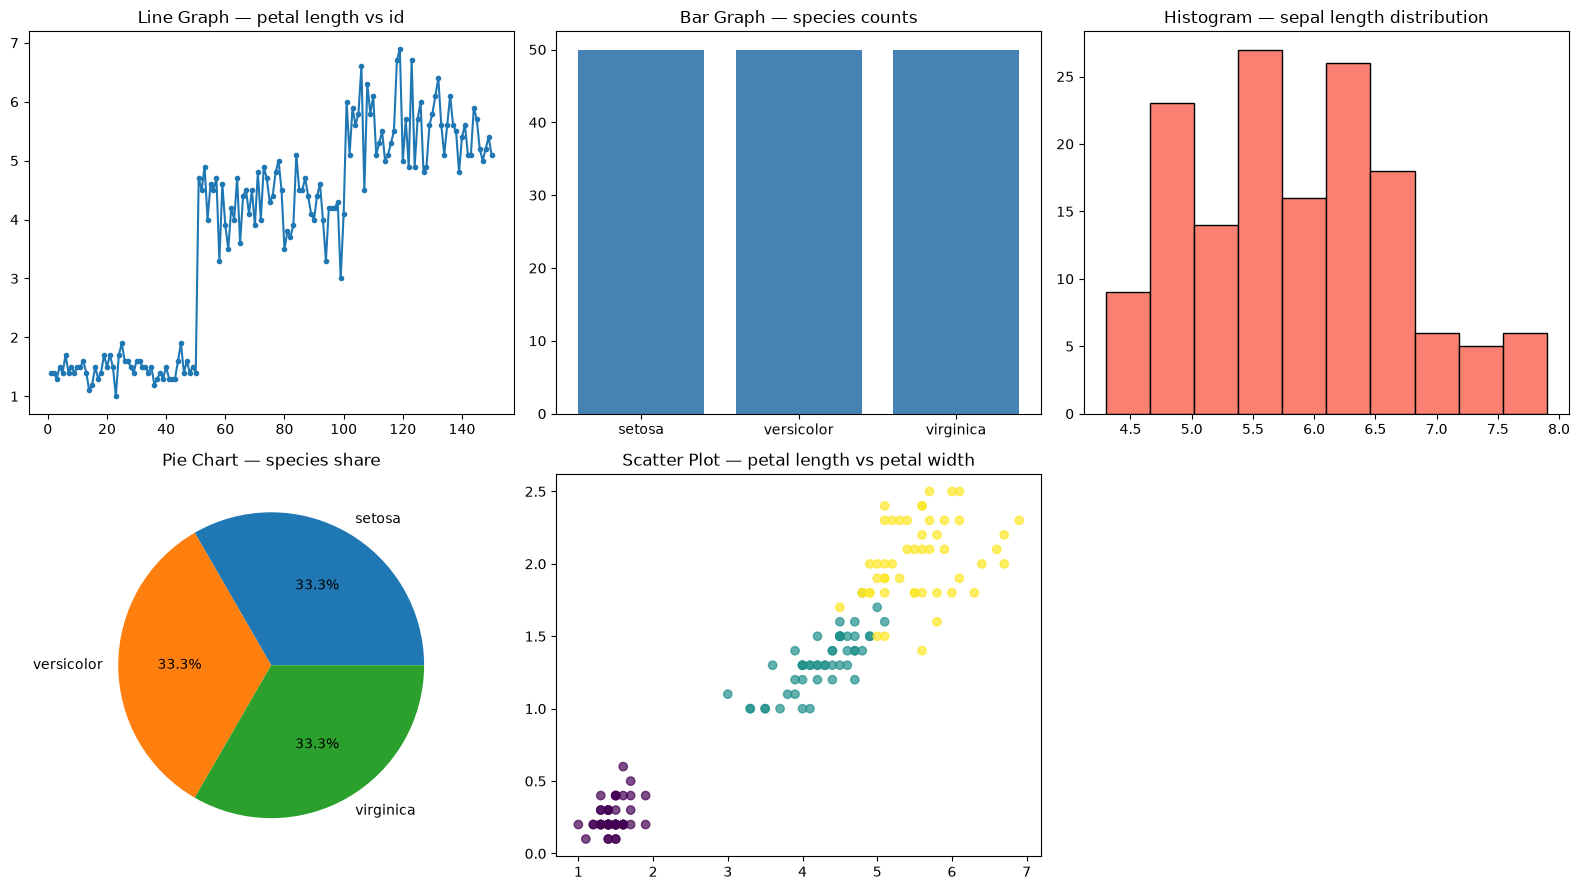

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Line graph
axes[0, 0].plot(df_csv["id"], df_csv["petal_length"], marker="o", ms=3)
axes[0, 0].set_title("Line Graph — petal length vs id")

# Bar graph
cat_counts = df_csv["species"].value_counts().sort_index()
axes[0, 1].bar(cat_counts.index, cat_counts.values, color="steelblue")
axes[0, 1].set_title("Bar Graph — species counts")

# Histogram
axes[0, 2].hist(df_csv["sepal_length"], bins=10, color="salmon", edgecolor="black")
axes[0, 2].set_title("Histogram — sepal length distribution")

# Pie chart
axes[1, 0].pie(cat_counts.values, labels=cat_counts.index, autopct="%1.1f%%")
axes[1, 0].set_title("Pie Chart — species share")

# Scatter plot
axes[1, 1].scatter(df_csv["petal_length"], df_csv["petal_width"], c=df_csv["target"], cmap="viridis", alpha=0.7)
axes[1, 1].set_title("Scatter Plot — petal length vs petal width")

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

### 2. Spreadsheet Data Formats — `.xlsx`, `.ods`

In [6]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df_wine = wine.frame.copy()
df_wine["target_name"] = df_wine["target"].map(dict(enumerate(wine.target_names)))
print("Wine dataset shape:", df_wine.shape)
df_wine.head()

Wine dataset shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [7]:
# .xlsx
df_wine.to_excel("data/sample.xlsx", index=False, engine="openpyxl")
df_xlsx = pd.read_excel("data/sample.xlsx", engine="openpyxl")
print(".xlsx shape:", df_xlsx.shape)
df_xlsx.head()

.xlsx shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0,class_0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0,class_0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0,class_0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0,class_0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0,class_0


In [8]:
# .ods (OpenDocument Spreadsheet)
df_wine.to_excel("data/sample.ods", index=False, engine="odf")
df_ods = pd.read_excel("data/sample.ods", engine="odf")
print(".ods shape:", df_ods.shape)
df_ods.head()

.ods shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0,class_0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0,class_0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0,class_0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0,class_0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0,class_0


### 3. Interchange Formats — `.json`, `.ubjson`, `.html`, `.xml`

In [9]:
import seaborn as sns

df_titanic = sns.load_dataset("titanic")  # downloaded from github.com/mwaskom/seaborn-data
print("Titanic dataset shape:", df_titanic.shape)
df_titanic.head()

Titanic dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
import json, ubjson

record = {
    "dataset": "titanic",
    "n_records": int(len(df_titanic)),
    "records": json.loads(df_titanic.head(5).to_json(orient="records")),
}

# JSON
with open("data/sample.json", "w") as f:
    json.dump(record, f, indent=2)
with open("data/sample.json") as f:
    loaded_json = json.load(f)
print("JSON keys:", list(loaded_json.keys()), "| records loaded:", len(loaded_json["records"]))

# UBJSON (binary JSON)
with open("data/sample.ubj", "wb") as f:
    ubjson.dump(record, f)
with open("data/sample.ubj", "rb") as f:
    loaded_ubj = ubjson.load(f)
print("UBJSON file size (bytes):", os.path.getsize("data/sample.ubj"), "| decoded OK:", loaded_ubj == record)

JSON keys: ['dataset', 'n_records', 'records'] | records loaded: 5
UBJSON file size (bytes): 1001 | decoded OK: True


In [11]:
# HTML
html_str = df_titanic.head(10).to_html(index=False)
with open("data/sample.html", "w") as f:
    f.write(f"<html><body><h2>Titanic Passengers (sample)</h2>{html_str}</body></html>")

parsed_tables = pd.read_html("data/sample.html")
print("Tables parsed from HTML:", len(parsed_tables))
parsed_tables[0].head()

Tables parsed from HTML: 1


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
# XML — using the Wine dataset
import re
from lxml import etree

def xml_safe_tag(name):
    return re.sub(r"[^0-9a-zA-Z_]", "_", str(name))

root = etree.Element("dataset", name="wine")
for _, row in df_wine.head(10).iterrows():
    rec = etree.SubElement(root, "record")
    for col, val in row.items():
        etree.SubElement(rec, xml_safe_tag(col)).text = str(val)
tree = etree.ElementTree(root)
tree.write("data/sample.xml", pretty_print=True, xml_declaration=True, encoding="UTF-8")

parsed_xml = etree.parse("data/sample.xml")
records = parsed_xml.findall("record")
print("XML records parsed:", len(records))
print("First record fields:", [child.tag for child in records[0]])

XML records parsed: 10
First record fields: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315_of_diluted_wines', 'proline', 'target', 'target_name']


### 4. Data File Formats — `.pkl`, `.h5` (HDF5), `.zip`, `.sql`, `.mat`, `.npy`, `.npz`

In [13]:
import pickle

# PKL — pickle the Iris DataFrame
with open("data/sample.pkl", "wb") as f:
    pickle.dump(df_tabular, f)
with open("data/sample.pkl", "rb") as f:
    df_pkl = pickle.load(f)
print(".pkl shape:", df_pkl.shape)

.pkl shape: (150, 7)


Digits dataset (real handwritten digits): (1797, 8, 8) (1797,)
.h5 datasets: ['images', 'labels']
images shape: (1797, 8, 8) dtype: float64


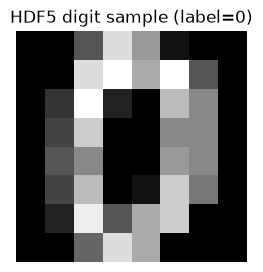

In [14]:
import h5py
from sklearn.datasets import load_digits

digits = load_digits()
print("Digits dataset (real handwritten digits):", digits.images.shape, digits.target.shape)

# HDF5
with h5py.File("data/sample.h5", "w") as f:
    f.create_dataset("images", data=digits.images)
    f.create_dataset("labels", data=digits.target)

with h5py.File("data/sample.h5", "r") as f:
    print(".h5 datasets:", list(f.keys()))
    print("images shape:", f["images"].shape, "dtype:", f["images"].dtype)
    h5_images = f["images"][:]

plt.figure(figsize=(3, 3))
plt.imshow(h5_images[0], cmap="gray")
plt.title(f"HDF5 digit sample (label={digits.target[0]})")
plt.axis("off")
plt.show()

In [15]:
import zipfile

# ZIP
with zipfile.ZipFile("data/sample.zip", "w") as zf:
    zf.write("data/sample.csv", arcname="iris.csv")
    zf.write("data/sample.json", arcname="titanic.json")

with zipfile.ZipFile("data/sample.zip", "r") as zf:
    print(".zip contents:", zf.namelist())
    print("info:", [(i.filename, i.file_size) for i in zf.infolist()])

.zip contents: ['iris.csv', 'titanic.json']
info: [('iris.csv', 4660), ('titanic.json', 1781)]


In [16]:
import sqlite3

# SQL (SQLite database file) — Titanic passengers
conn = sqlite3.connect("data/sample.sql")
df_titanic.to_sql("passengers", conn, if_exists="replace", index=False)
df_sql = pd.read_sql("SELECT * FROM passengers LIMIT 10", conn)
conn.close()
print(".sql (sqlite) shape read back:", df_sql.shape)
df_sql.head()

.sql (sqlite) shape read back: (10, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,1,NaN,Southampton,no,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,0,C,Cherbourg,yes,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,0,NaN,Southampton,yes,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,0,C,Southampton,yes,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,1,NaN,Southampton,no,1


.mat keys: ['raccoon_face']
raccoon_face shape: (768, 1024, 3)


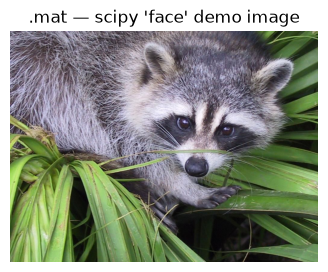

In [17]:
from scipy.io import savemat, loadmat
from scipy.datasets import face

# MAT (MATLAB) — SciPy's classic "raccoon face" demo image
raccoon = face()
savemat("data/sample.mat", {"raccoon_face": raccoon})
mat_data = loadmat("data/sample.mat")
print(".mat keys:", [k for k in mat_data if not k.startswith("__")])
print("raccoon_face shape:", mat_data["raccoon_face"].shape)

plt.figure(figsize=(4, 3))
plt.imshow(mat_data["raccoon_face"])
plt.title(".mat — scipy 'face' demo image")
plt.axis("off")
plt.show()

In [18]:
# NPY / NPZ — Digits dataset arrays
np.save("data/sample.npy", digits.images)
np.savez("data/sample.npz", images=digits.images, labels=digits.target)

loaded_npy = np.load("data/sample.npy")
loaded_npz = np.load("data/sample.npz")
print(".npy shape:", loaded_npy.shape, "dtype:", loaded_npy.dtype)
print(".npz arrays:", loaded_npz.files, "| images shape:", loaded_npz["images"].shape)

.npy shape: (1797, 8, 8) dtype: float64
.npz arrays: ['images', 'labels'] | images shape: (1797, 8, 8)


### 5. Image Data Formats — `.jpg`, `.png`, `.bmp`, `.tiff`, DICOM (`.dcm`), `.mha`

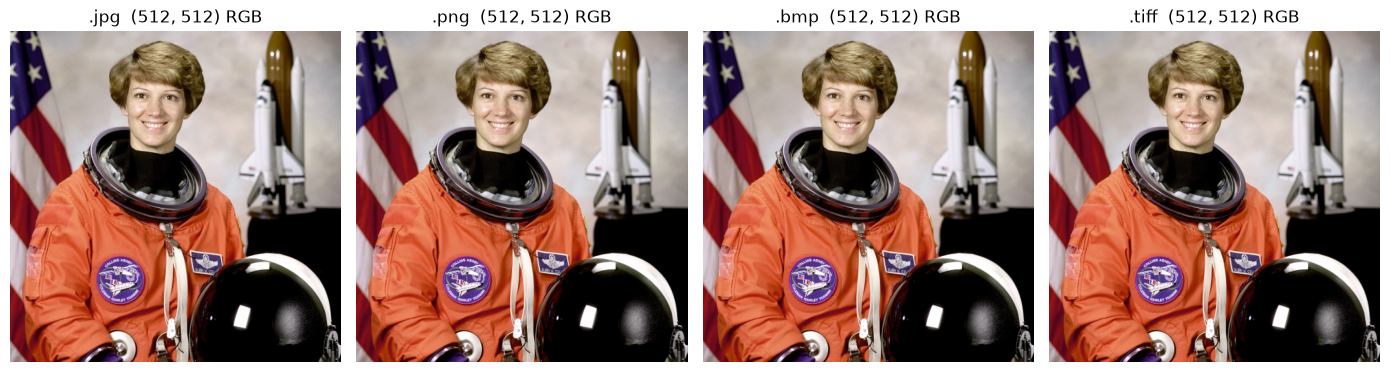

In [19]:
from PIL import Image
from skimage import data as skdata

# scikit-image's canonical "astronaut" (Eileen Collins) RGB test image
astronaut = skdata.astronaut()
img = Image.fromarray(astronaut, "RGB")

img.save("data/sample.jpg", quality=90)
img.save("data/sample.png")
img.save("data/sample.bmp")
img.save("data/sample.tiff")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, ext in zip(axes, ["jpg", "png", "bmp", "tiff"]):
    im = Image.open(f"data/sample.{ext}")
    ax.imshow(im)
    ax.set_title(f".{ext}  {im.size} {im.mode}")
    ax.axis("off")
plt.tight_layout()
plt.show()

DICOM source: /Users/swapnil/Documents/NLP/venv/lib/python3.13/site-packages/pydicom/data/test_files/CT_small.dcm
Rows x Columns: 128 x 128 | Modality: CT


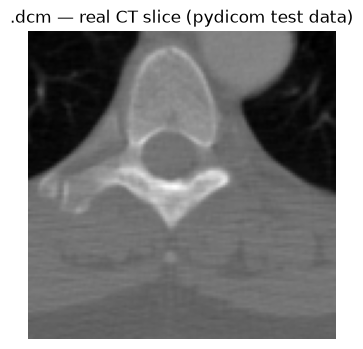

In [20]:
import pydicom
import pydicom.data

# Real anonymized CT slice bundled as pydicom test data
dcm_path = pydicom.data.get_testdata_file("CT_small.dcm")
loaded_dcm = pydicom.dcmread(dcm_path)
print("DICOM source:", dcm_path)
print("Rows x Columns:", loaded_dcm.Rows, "x", loaded_dcm.Columns, "| Modality:", loaded_dcm.Modality)

import shutil
shutil.copy(dcm_path, "data/sample.dcm")

plt.figure(figsize=(4, 4))
plt.imshow(loaded_dcm.pixel_array, cmap="gray")
plt.title(".dcm — real CT slice (pydicom test data)")
plt.axis("off")
plt.show()

.mha size (x,y,z): (256, 256, 60) | array shape: (60, 256, 256)


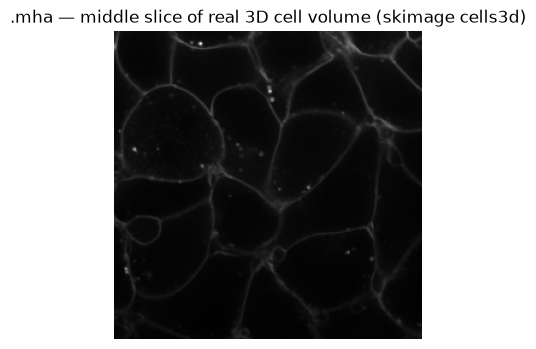

In [21]:
import SimpleITK as sitk

# .mha (MetaImage) — 3D volume, using scikit-image's real "cells3d" fluorescence
# microscopy dataset (nuclei + membrane channels of mouse kidney tissue)
cells = skdata.cells3d()  # shape: (z, channel, y, x)
volume = cells[:, 0, :, :]  # nuclei channel only

sitk_img = sitk.GetImageFromArray(volume)
sitk.WriteImage(sitk_img, "data/sample.mha")

loaded_mha = sitk.ReadImage("data/sample.mha")
mha_array = sitk.GetArrayFromImage(loaded_mha)
print(".mha size (x,y,z):", loaded_mha.GetSize(), "| array shape:", mha_array.shape)

plt.figure(figsize=(4, 4))
plt.imshow(mha_array[mha_array.shape[0] // 2], cmap="gray")
plt.title(".mha — middle slice of real 3D cell volume (skimage cells3d)")
plt.axis("off")
plt.show()

### 6. Video Data Formats — `.mp4`, `.avi`, `.mpeg`

In [22]:
import cv2
import urllib.request

video_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi"
raw_video_path = "data/vtest_source.avi"
urllib.request.urlretrieve(video_url, raw_video_path)
print("Downloaded", raw_video_path, "-", os.path.getsize(raw_video_path), "bytes")

cap = cv2.VideoCapture(raw_video_path)
src_fps = cap.get(cv2.CAP_PROP_FPS)
src_size = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
print("Source video fps:", src_fps, "| size:", src_size)

# Keep the notebook lightweight: trim to the first 45 frames, resized down
out_size = (320, 240)
frames = []
for _ in range(45):
    ok, frame = cap.read()
    if not ok:
        break
    frames.append(cv2.resize(frame, out_size))
cap.release()
print("Frames captured for re-encoding:", len(frames))

Downloaded data/vtest_source.avi - 8131690 bytes
Source video fps: 10.0 | size: (768, 576)
Frames captured for re-encoding: 45


In [23]:
def write_video(path, fourcc_str, fps, frames, size):
    fourcc = cv2.VideoWriter_fourcc(*fourcc_str)
    writer = cv2.VideoWriter(path, fourcc, fps, size)
    for frame in frames:
        writer.write(frame)
    writer.release()

write_video("data/sample.mp4", "mp4v", 15, frames, out_size)
write_video("data/sample.avi", "MJPG", 15, frames, out_size)
write_video("data/sample.mpeg", "PIM1", 25, frames, out_size)  # MPEG-1 program stream requires a standard frame rate (25 fps)

for path in ["data/sample.mp4", "data/sample.avi", "data/sample.mpeg"]:
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    wxh = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    n = 0
    while True:
        ok, _ = cap.read()
        if not ok:
            break
        n += 1
    print(f"{path}: frames_read={n}, fps={fps}, size={wxh}")
    cap.release()

data/sample.mp4: frames_read=45, fps=15.0, size=(320, 240)
data/sample.avi: frames_read=45, fps=15.0, size=(320, 240)
data/sample.mpeg: frames_read=45, fps=25.0, size=(320, 240)


OpenCV: FFMPEG: tag 0x314d4950/'PIM1' is not supported with codec id 1 and format 'mpeg / MPEG-1 Systems / MPEG program stream'


In [24]:
from IPython.display import Video, display

# Video player (inline, .mp4 plays natively in browsers)
display(Video("data/sample.mp4", embed=True, width=240))

### 7. Audio Data Formats — `.mp3`, `.midi`, `.wav`

In [25]:
import soundfile as sf
import librosa

# WAV — librosa's real bundled "trumpet" solo recording
wav_data, sr = librosa.load(librosa.example("trumpet"), sr=22050)
sf.write("data/sample.wav", wav_data, sr)

wav_data, wav_sr = sf.read("data/sample.wav")
print(".wav samples:", wav_data.shape, "| sample rate:", wav_sr, "| duration (s):", round(len(wav_data) / wav_sr, 2))

.wav samples: (117601,) | sample rate: 22050 | duration (s): 5.33


In [26]:
from pydub import AudioSegment
from IPython.display import Audio, display

# MP3 (encoded from the WAV via pydub/ffmpeg)
try:
    AudioSegment.from_wav("data/sample.wav").export("data/sample.mp3", format="mp3")
    mp3_seg = AudioSegment.from_mp3("data/sample.mp3")
    print(".mp3 duration (ms):", len(mp3_seg), "| channels:", mp3_seg.channels, "| frame_rate:", mp3_seg.frame_rate)
except Exception as e:
    print("MP3 encode/decode needs ffmpeg + an mp3 encoder on PATH:", e)

display(Audio("data/sample.wav"))

.mp3 duration (ms): 5333 | channels: 1 | frame_rate: 22050


In [27]:
import pretty_midi
from music21 import corpus

# MIDI — a real J.S. Bach chorale (BWV 66.6) from music21's bundled corpus
bach_score = corpus.parse("bach/bwv66.6")
bach_score.write("midi", fp="data/sample.midi")

loaded_midi = pretty_midi.PrettyMIDI("data/sample.midi")
print("Source: J.S. Bach, Chorale BWV 66.6 (music21 corpus)")
print(".midi instruments:", len(loaded_midi.instruments))
print(".midi total notes:", sum(len(inst.notes) for inst in loaded_midi.instruments))
print(".midi duration (s):", round(loaded_midi.get_end_time(), 2))

Source: J.S. Bach, Chorale BWV 66.6 (music21 corpus)
.midi instruments: 4
.midi total notes: 163
.midi duration (s): 22.5


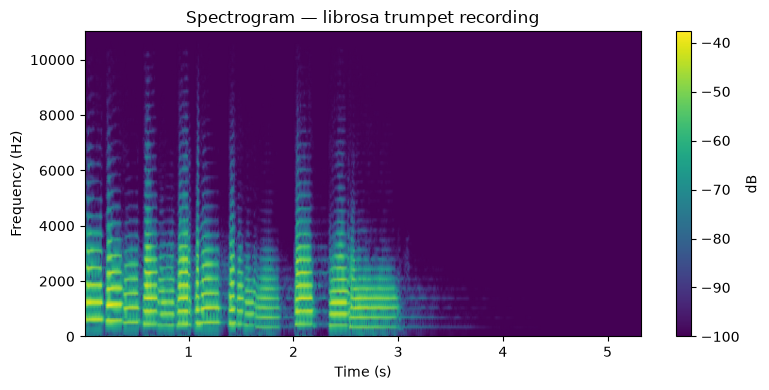

In [28]:
import scipy.signal as signal

# Spectrogram of the real trumpet recording
f, t_spec, Sxx = signal.spectrogram(wav_data, wav_sr)
plt.figure(figsize=(8, 4))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading="gouraud")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrogram — librosa trumpet recording")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

### 8. Text Data Formats — `.txt`, `.pdf`, `.doc(x)`

In [29]:
import nltk
nltk.download("gutenberg", quiet=True)
from nltk.corpus import gutenberg

alice_raw = gutenberg.raw("carroll-alice.txt")
sample_text = alice_raw[:1200].strip()
print("Source: Lewis Carroll, 'Alice's Adventures in Wonderland' (nltk.corpus.gutenberg)")
print(sample_text[:300], "...")

# TXT
with open("data/sample.txt", "w") as f:
    f.write(sample_text)
with open("data/sample.txt") as f:
    txt_content = f.read()
print("\n.txt characters written:", len(txt_content))

Source: Lewis Carroll, 'Alice's Adventures in Wonderland' (nltk.corpus.gutenberg)
[Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversatio ...

.txt characters written: 1200


In [30]:
from reportlab.pdfgen import canvas
from pypdf import PdfReader

# PDF
c = canvas.Canvas("data/sample.pdf")
c.drawString(72, 750, "Natural Language Processing — Sample PDF")
c.drawString(72, 730, sample_text)
c.save()

reader = PdfReader("data/sample.pdf")
print(".pdf pages:", len(reader.pages))
print(".pdf extracted text:", reader.pages[0].extract_text())

.pdf pages: 1
.pdf extracted text: Natural Language Processing — Sample PDF
[Alice's Adventures in Wonderland by Lewis Carroll 1865]■■CHAPTER I. Down the Rabbit-Hole■■Alice was beginning to get very tired of sitting by her sister on the■bank, and of having nothing to do: once or twice she had peeped into the■book her sister was reading, but it had no pictures or conversations in■it, 'and what is the use of a book,' thought Alice 'without pictures or■conversation?'■■So she was considering in her own mind (as well as she could, for the■hot day made her feel very sleepy and stupid), whether the pleasure■of making a daisy-chain would be worth the trouble of getting up and■picking the daisies, when suddenly a White Rabbit with pink eyes ran■close by her.■■There was nothing so VERY remarkable in that; nor did Alice think it so■VERY much out of the way to hear the Rabbit say to itself, 'Oh dear!■Oh dear! I shall be late!' (when she thought it over afterwards, it■occurred to her that she ought

In [31]:
import docx

# DOC (as modern .docx, python-docx cannot write legacy binary .doc)
document = docx.Document()
document.add_heading("Sample Document", level=1)
document.add_paragraph(sample_text)
document.save("data/sample.docx")

loaded_doc = docx.Document("data/sample.docx")
print(".docx paragraphs:", len(loaded_doc.paragraphs))
for p in loaded_doc.paragraphs:
    print("-", p.text)

.docx paragraphs: 2
- Sample Document
- [Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversations in
it, 'and what is the use of a book,' thought Alice 'without pictures or
conversation?'

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure
of making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a White Rabbit with pink eyes ran
close by her.

There was nothing so VERY remarkable in that; nor did Alice think it so
VERY much out of the way to hear the Rabbit say to itself, 'Oh dear!
Oh dear! I shall be late!' (when she thought it over afterwards, it
occurred to her that she ought to have wondered at this, but at th

### 9. Text Visualization — Word Cloud & Bubble Chart

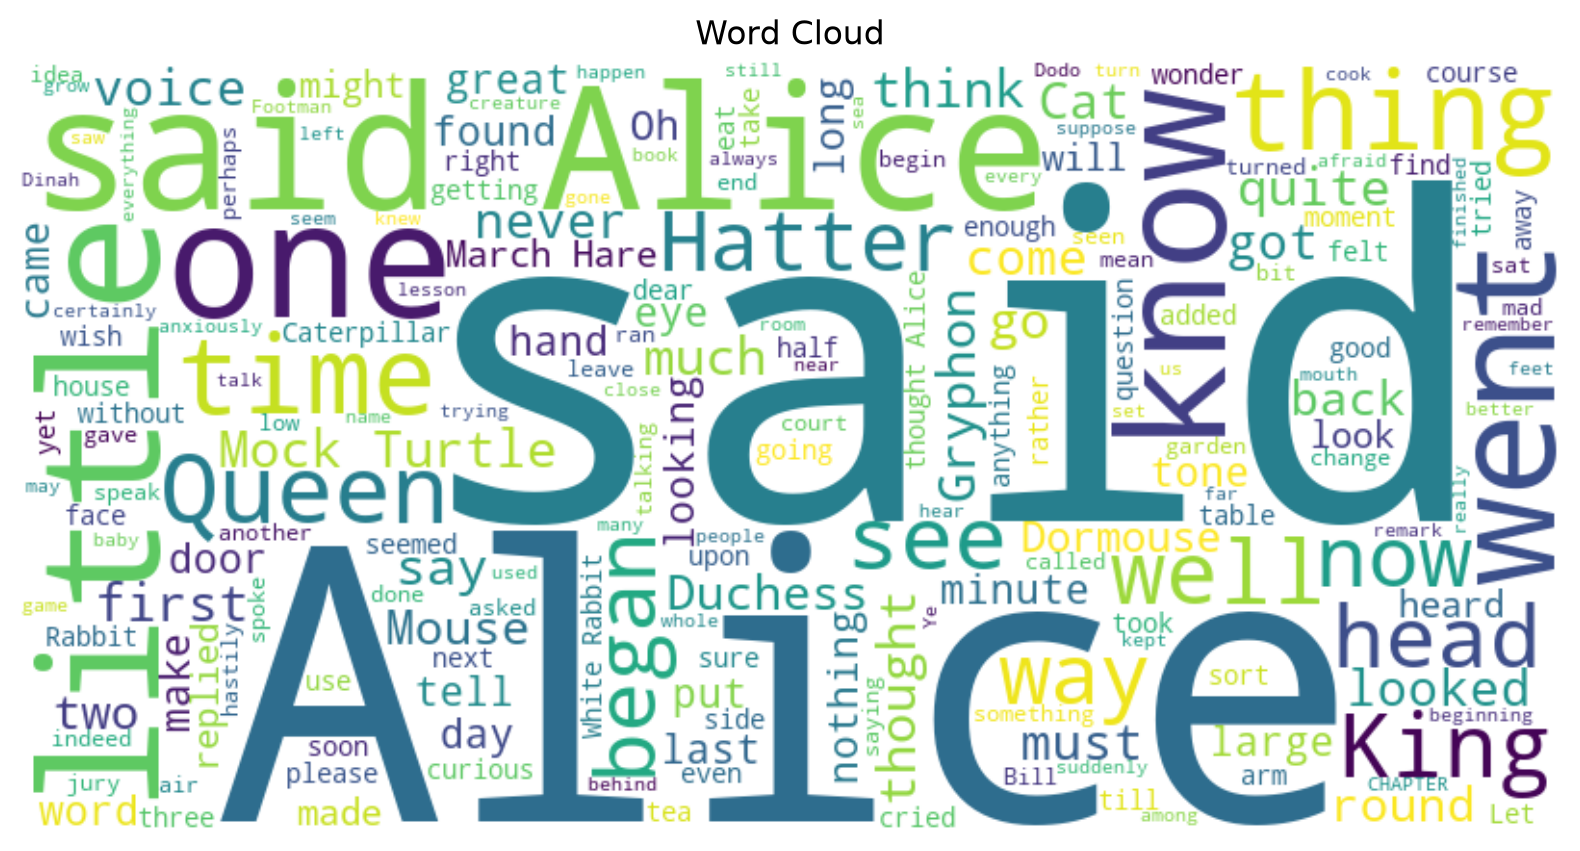

In [32]:
from wordcloud import WordCloud

corpus_text = alice_raw  # the full novel, not just the excerpt written to sample.txt
wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(corpus_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

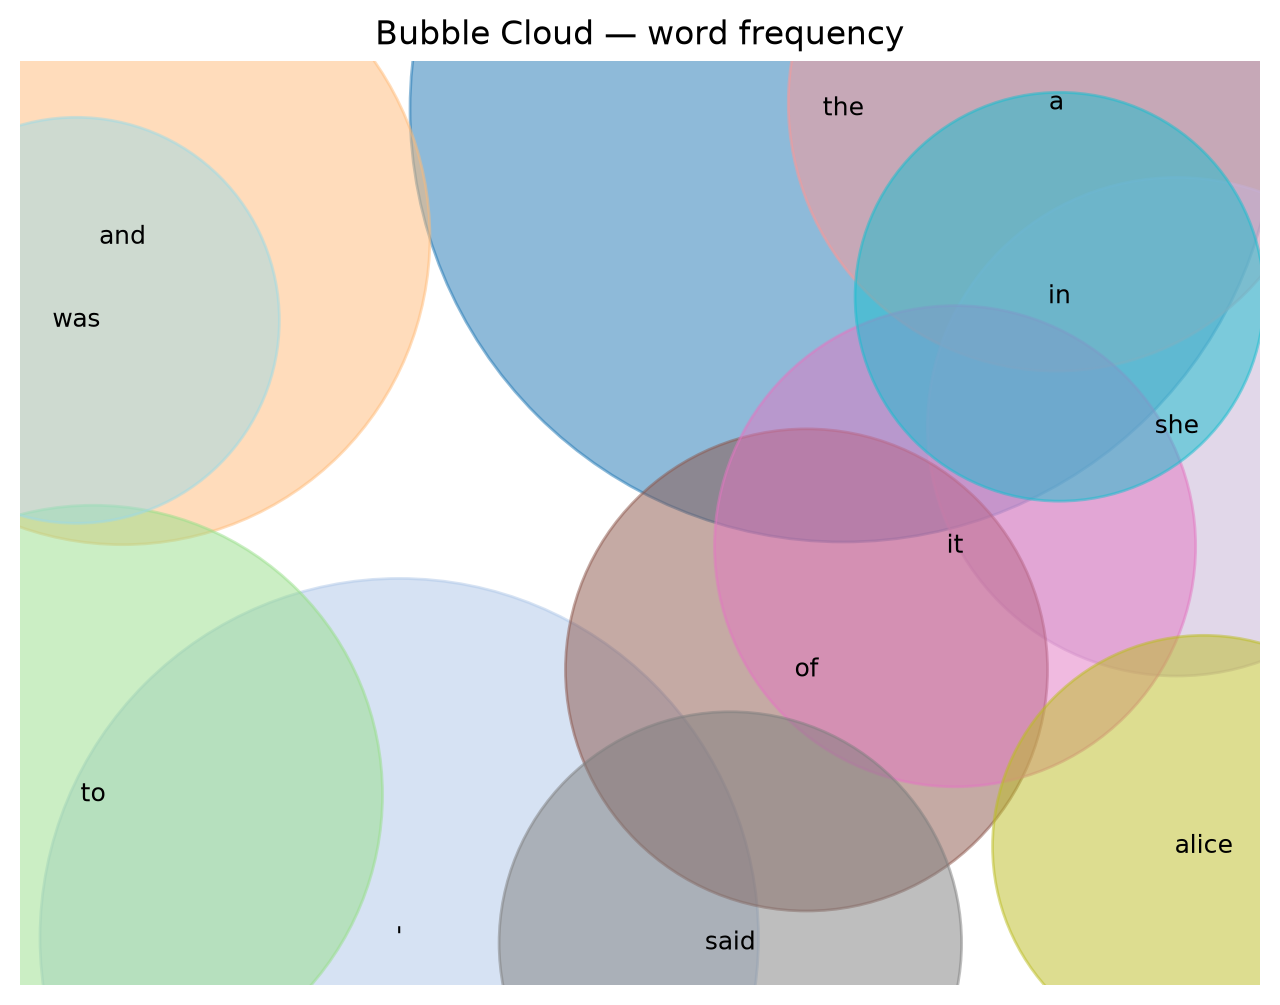

In [33]:
# Bubble chart (word frequency encoded as bubble size)
from collections import Counter
import re as regex_mod

words = regex_mod.findall(r"[a-zA-Z']+", corpus_text.lower())
freqs = Counter(words).most_common(12)
labels, counts = zip(*freqs)

rng = np.random.default_rng(0)
x = rng.uniform(0, 10, len(labels))
y = rng.uniform(0, 10, len(labels))
sizes = np.array(counts) * 60

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=sizes, alpha=0.5, c=range(len(labels)), cmap="tab20")
for xi, yi, label in zip(x, y, labels):
    plt.text(xi, yi, label, ha="center", va="center", fontsize=9)
plt.title("Bubble Cloud — word frequency")
plt.axis("off")
plt.show()

## Task 2 — Text Data Cleaning, Tokenization & Normalization

In [34]:
import re

raw_paragraphs = [
    "OMG!! I can't believe I found this aWesoMe article about AI & machine leanring!! "
    "It was soooo gooood lol. I <3 nlp buttt i hate spelng errors in textttt. This is "
    "gonna be a looong paragraph with looooots of spacess and weirddddd symbols @#$%. "
    "The website's link is www.example.com//// Check it out ASAP!!! #excited",

    "Oh my gosh!!! Like, I can't even believe what I just stumbled upon on the world wide "
    "web. This article, \"The Marvels of Artificial General Intelligence & the Future of "
    "Humanity,\" totally blew my mindddd!! It was, like, sooo mind-blowingly awesome, lolz. "
    "I mean, I <3 NLP butttt those annoying typos in texts drive me nuts. Brace yourselves, "
    "this is gonna be one seriously long paragraph with tons and tons of extraterrestrial "
    "spaces and some seriously weird symbols like @#$%. And guess what? The link to the "
    "website is www.incrediblenews.com//// So, um, you better check it out like ASAP!!! "
    "#excitedmuch",

    "yaaayyyyy!!! just watched thissssss AMAZZZZING vid on AI \U0001F440 & how it's "
    "changin' evrythingggg!! \U0001F62D\U0001F62D it waz soooo dopeee, i can't even... "
    "lolzzz! #blessed #mindblownn... btw, the link is http://coolai.stuff.com//// totally "
    "worthhh ittttttt @@@!!! i <3 tech so much but sometimes it's like reallllyy "
    "confusingggg!!!",

    "nooo waayyyyyy!!!! \U0001F62D \U0001F62D this is, like, the 1000000th time i've "
    "seen ppl mess up spellings in their blogssss \U0001F62D i mean c'mon, u're writing "
    "abt deep learning, not sum joke topic \U0001F644 anywayzzzz... the article was kinda "
    "coooool butttt had lotsa weird $$$%%%@@ symbols all over. you can read it @ "
    "www.badblogger.ai//// and let me knw ur thots ASAP!!!",

    "heyyyyy, did u read that crazyyyyyyy article on quantum stuff & ai?? like for "
    "realll... it wuz crazzzzy detailed but sooooo complicateddd!!! i cud barely undrstnd "
    "half of it \U0001F92F \U0001F92F. the diagrams were \U0001F525 \U0001F525 tho!!! "
    "i found it here \u2013 www.quantmgeekzz.net//// \u2026 plz plz plz read n tell me "
    "what u thinkk \U0001F62D \U0001F62D #toomuchinfo #brainhurts @@@!!!",
]
print(f"Loaded {len(raw_paragraphs)} raw paragraphs.")

Loaded 5 raw paragraphs.


In [35]:
# Step-by-step cleaning pipeline

CONTRACTIONS = {
    "can't": "cannot", "cant": "cannot", "i'm": "i am", "it's": "it is",
    "that's": "that is", "don't": "do not", "won't": "will not",
    "isn't": "is not", "u're": "you are", "u'": "you", "i've": "i have",
    "didn't": "did not", "wasn't": "was not", "'s": " is",
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(re.escape(k), v, text)
    return text

def clean_paragraph(text):
    text = text.lower()                                        # 1. lowercasing
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)          # 7. remove URLs (also strips trailing slashes)
    text = re.sub(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", " ", text)  # strip emoji
    text = expand_contractions(text)                            # 3. handling contractions
    text = re.sub(r"<3", "love", text)
    text = re.sub(r'[@#$%^&*_+=\[\]{}|\\/<>~`"]', "", text)     # 4. remove special characters
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)                    # 5. reduce 3+ repeated letters to 2
    text = re.sub(r"\b(\w*?)\1{2,}\b", r"\1", text)               # collapse doubled letters left after step 5, e.g. "soo"->"so"...
    text = re.sub(r"[!?.]{2,}", ".", text)                      # 6. fixing punctuation
    text = re.sub(r"\.\.\.", ".", text)
    text = re.sub(r"\s+", " ", text).strip()                     # 2. remove extra whitespace
    text = re.sub(r"\s([?.!,](?:\s|$))", r"\1", text)             # no space before punctuation
    return text

cleaned_paragraphs = [clean_paragraph(p) for p in raw_paragraphs]
for i, c in enumerate(cleaned_paragraphs, 1):
    print(f"Paragraph {i} (cleaned):\n{c}\n")

Paragraph 1 (cleaned):
omg. i cannot believe i found this awesome article about ai machine leanring. it was soo good lol. i love nlp butt i hate spelng errors in textt. this is gonna be a loong paragraph with loots of spacess and weirdd symbols. the website is link is check it out asap. excited

Paragraph 2 (cleaned):
oh my gosh. like, i cannot even believe what i just stumbled upon on the world wide web. this article, the marvels of artificial general intelligence the future of humanity, totally blew my mindd. it was, like, soo mind-blowingly awesome, lolz. i mean, i love nlp butt those annoying typos in texts drive me nuts. brace yourselves, this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like. and guess what? the link to the website is so, um, you better check it out like asap. excitedmuch

Paragraph 3 (cleaned):
yaayy. just watched thiss amazzing vid on ai how it is changin' evrythingg. it waz soo dopee, i

In [36]:
# 1. Load and Tokenize Text (Brown corpus)
import nltk
from nltk.corpus import brown

category = "news"
brown_words = brown.words(categories=category)
brown_text = " ".join(brown_words)
tokens = nltk.word_tokenize(brown_text)

print(f"Brown corpus category: '{category}'")
print("Total characters in string:", len(brown_text))
print("Total tokens:", len(tokens))
print("First 20 tokens:", tokens[:20])

Brown corpus category: 'news'
Total characters in string: 543146
Total tokens: 101937
First 20 tokens: ['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', '``']


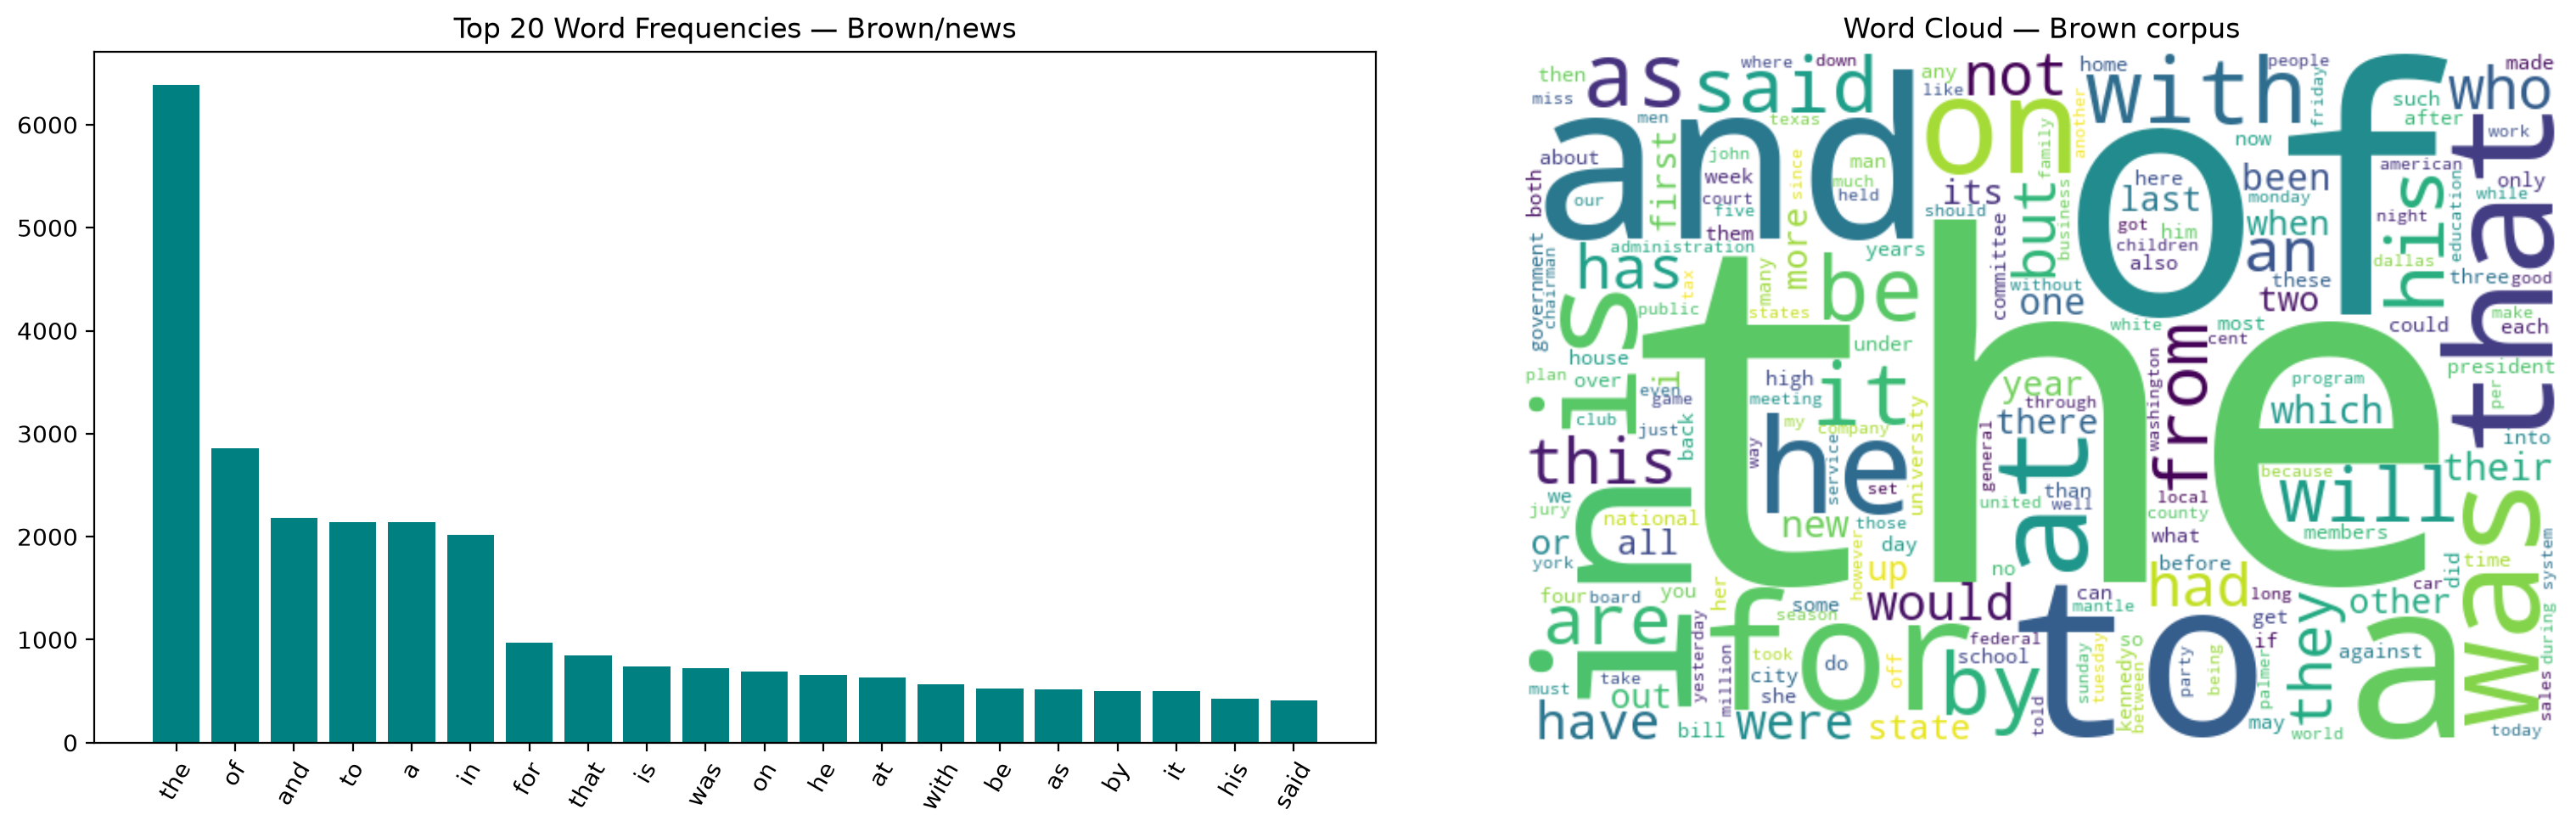

In [37]:
# 2. Visualize Raw Word Frequencies
from nltk import FreqDist
from wordcloud import WordCloud

alpha_tokens = [t.lower() for t in tokens if t.isalpha()]
fdist = FreqDist(alpha_tokens)
top20 = fdist.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words, counts = zip(*top20)
axes[0].bar(words, counts, color="teal")
axes[0].set_title(f"Top 20 Word Frequencies — Brown/{category}")
axes[0].tick_params(axis="x", rotation=60)

wc = WordCloud(width=600, height=400, background_color="white").generate_from_frequencies(fdist)
axes[1].imshow(wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud — Brown corpus")

plt.tight_layout()
plt.show()

In [38]:
# 3. Apply Stemming (PorterStemmer)
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(w) for w in alpha_tokens]
stemmed_fdist = FreqDist(stemmed_tokens)

print("Sample stemmed words with frequency:")
for word, freq in stemmed_fdist.most_common(20):
    print(f"  {word:<15} {freq}")

Sample stemmed words with frequency:
  the             6386
  of              2861
  and             2186
  to              2144
  a               2139
  in              2020
  for             969
  that            843
  is              740
  wa              720
  on              691
  it              682
  he              658
  at              636
  be              583
  with            567
  as              517
  by              504
  hi              428
  said            406


In [39]:
# 4. Apply Lemmatization (WordNetLemmatizer)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(w) for w in alpha_tokens]
lemma_fdist = FreqDist(lemmatized_tokens)

print("Sample lemmatized words with frequency:")
for word, freq in lemma_fdist.most_common(20):
    print(f"  {word:<15} {freq}")

Sample lemmatized words with frequency:
  the             6386
  of              2861
  a               2656
  and             2186
  to              2144
  in              2020
  for             969
  that            843
  is              740
  wa              720
  on              691
  it              682
  he              658
  at              636
  with            567
  be              526
  by              504
  his             428
  said            406
  will            389


,original_word,original_count,stemmed_form,stemmed_count,lemmatized_form,lemmatized_count
0,the,6386,the,6386,the,6386
1,of,2861,of,2861,of,2861
2,and,2186,and,2186,and,2186
3,to,2144,to,2144,to,2144
4,a,2139,a,2139,a,2656
5,in,2020,in,2020,in,2020
6,for,969,for,969,for,969
7,that,843,that,843,that,843
8,is,740,is,740,is,740
9,was,720,wa,720,wa,720


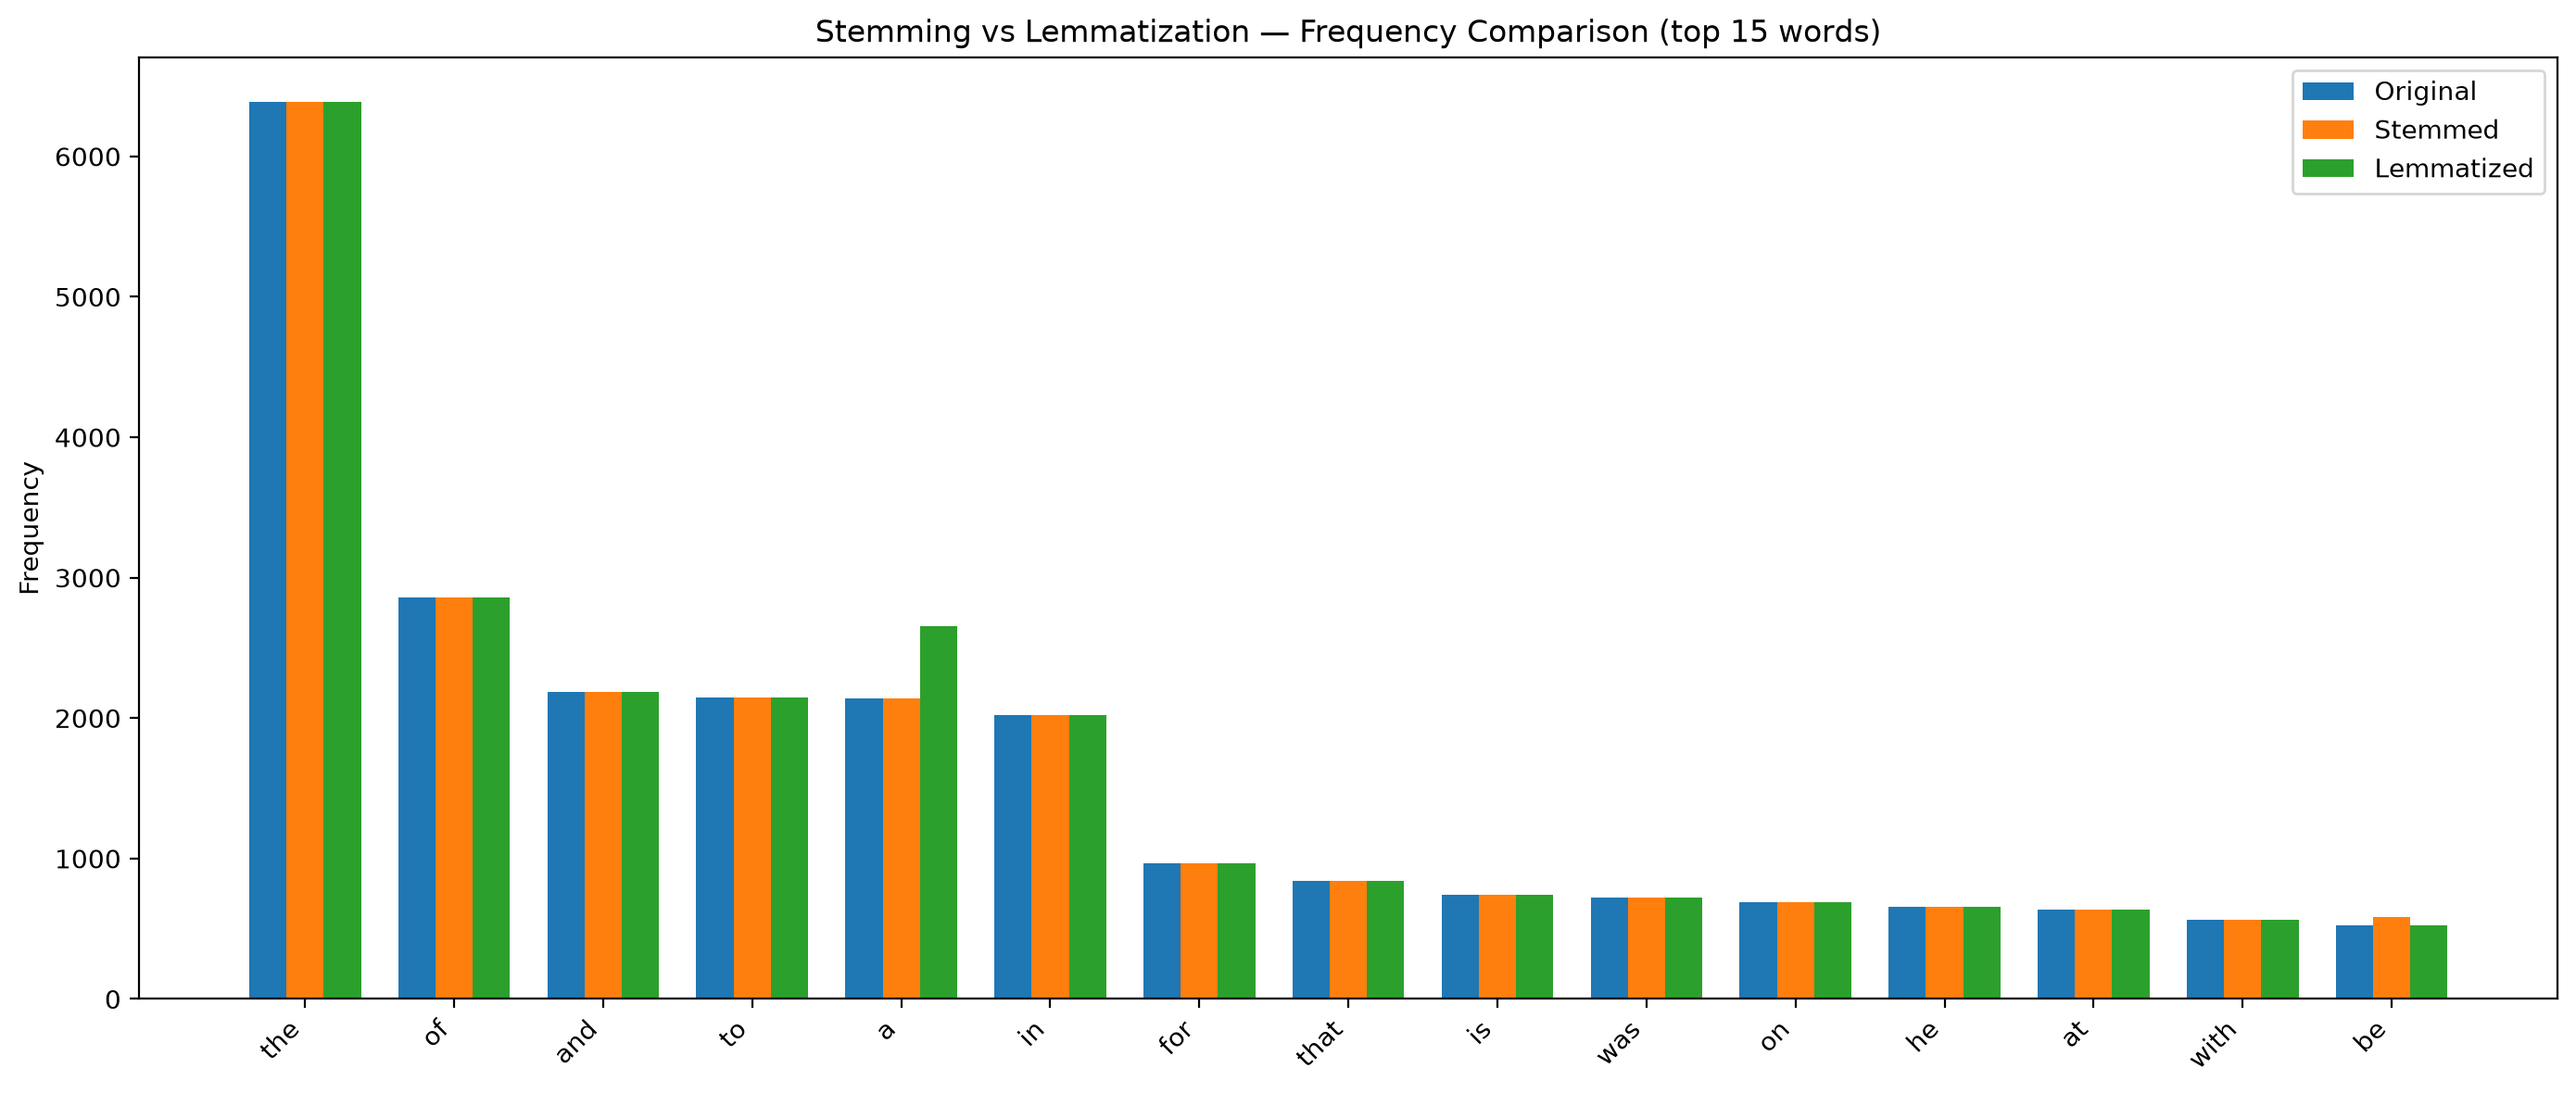

In [40]:
# 5. Compare Stemming vs Lemmatization
common_words = [w for w, _ in fdist.most_common(15)]

comparison = pd.DataFrame({
    "original_word": common_words,
    "original_count": [fdist[w] for w in common_words],
    "stemmed_form": [stemmer.stem(w) for w in common_words],
    "stemmed_count": [stemmed_fdist[stemmer.stem(w)] for w in common_words],
    "lemmatized_form": [lemmatizer.lemmatize(w) for w in common_words],
    "lemmatized_count": [lemma_fdist[lemmatizer.lemmatize(w)] for w in common_words],
})
display(comparison)

x = np.arange(len(common_words))
width = 0.25
plt.figure(figsize=(14, 6))
plt.bar(x - width, comparison["original_count"], width, label="Original")
plt.bar(x, comparison["stemmed_count"], width, label="Stemmed")
plt.bar(x + width, comparison["lemmatized_count"], width, label="Lemmatized")
plt.xticks(x, common_words, rotation=45, ha="right")
plt.ylabel("Frequency")
plt.title("Stemming vs Lemmatization — Frequency Comparison (top 15 words)")
plt.legend()
plt.tight_layout()
plt.show()